# 02 - Exploratory Data Analysis

Goal: understand distributions, churn by segment, and data quality issues before preparing the modeling dataset.

The focus is separating useful signals from variables that could introduce bias or leakage.

In [1]:
import churn_analysis_portfolio.missing  # registers df.missing


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import missingno
import upsetplot

sns.set_style("whitegrid")

DATA_PATH = "../data/Customer_Data.csv"
TARGET_COL = "Customer_Status"
MONTHLY_CHARGE_COL = "Monthly_Charge"
INTERNET_DEPENDENT_COLS = [
    "Internet_Type",
    "Online_Security",
    "Online_Backup",
    "Device_Protection_Plan",
    "Premium_Support",
    "Streaming_TV",
    "Streaming_Movies",
    "Streaming_Music",
    "Unlimited_Data",
]

df = pd.read_csv(DATA_PATH)
df_model = df[df[TARGET_COL].isin(["Stayed", "Churned"])].copy()
df_joined = df[df[TARGET_COL] == "Joined"].copy()

## Numeric variables (df_model)

In [3]:
numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months",
    "Monthly_Charge", "Total_Charges", "Total_Revenue",
]
df_model[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,6007.0,47.289163,16.805110,18.00,33.000,47.00,60.000,84.00
Number_of_Referrals,6007.0,7.439820,4.622369,0.00,3.000,7.00,11.000,15.00
Tenure_in_Months,6007.0,17.394540,10.592920,1.00,8.000,17.00,27.000,36.00
Monthly_Charge,6007.0,65.087598,31.067808,-10.00,35.950,71.10,90.450,118.75
Total_Charges,6007.0,2430.986173,2267.481294,19.10,539.950,1556.85,4013.900,8684.80
Total_Revenue,6007.0,3233.246021,2856.181082,21.61,833.685,2367.15,5105.685,11979.34


## Churn rate by segment

Four categorical variables with uneven customer volume across categories are compared (`Contract`, `Internet_Service`, `Value_Deal`, `Payment_Method`). That's why each bar also shows `n`: a high churn rate computed over few customers shouldn't be read the same way as one computed over thousands.

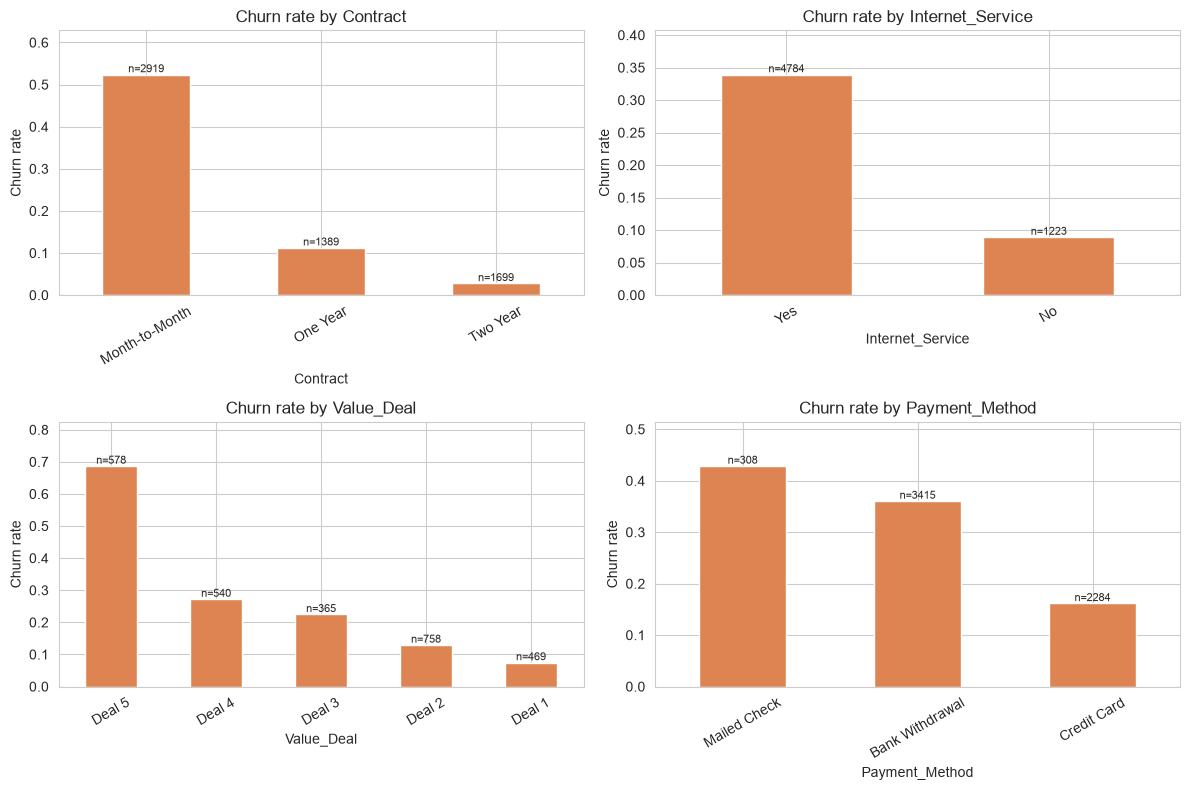

In [4]:
segment_cols = ["Contract", "Internet_Service", "Value_Deal", "Payment_Method"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, segment_cols):
    grouped = df_model.groupby(col)[TARGET_COL]
    churn_rate = grouped.apply(lambda s: (s == "Churned").mean()).sort_values(ascending=False)
    counts = grouped.size().reindex(churn_rate.index)

    bars = churn_rate.plot(kind="bar", ax=ax, color="#DD8452")
    for bar, n in zip(bars.patches, counts):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height(),
            f"n={n}", ha="center", va="bottom", fontsize=8,
        )
    ax.set_title(f"Churn rate by {col}")
    ax.set_ylabel("Churn rate")
    ax.set_ylim(0, churn_rate.max() * 1.2)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Anomaly: negative `Monthly_Charge`

The dataset contains 107 rows (1.7%) with a negative `Monthly_Charge`, ranging from -1 to -10. A negative monthly charge has no obvious business interpretation on its own -- it could be a real discount/refund, or a data-entry error. The pattern needs to be examined before deciding what to do with these rows.

In [5]:
negative_mask = df[MONTHLY_CHARGE_COL] < 0
print(f"Rows with negative Monthly_Charge: {negative_mask.sum()} ({negative_mask.mean():.1%})")
df.loc[negative_mask, MONTHLY_CHARGE_COL].value_counts().sort_index()

Rows with negative Monthly_Charge: 107 (1.7%)


Monthly_Charge
-10.0    12
-9.0      8
-8.0     12
-7.0     14
-6.0      5
-5.0     11
-4.0     14
-3.0     11
-2.0     10
-1.0     10
Name: count, dtype: int64

All 107 values are whole numbers (-1, -2, ..., -10, no decimals). A real discount or refund would inherit cents like the rest of the base -- if they are round numbers with that much consistency, they are more likely to be synthetic values than a real business rule. The proportion of whole-number values between negative and non-negative rows is compared to confirm this.

In [6]:
is_whole_number = lambda s: (s.dropna() % 1 == 0)

negative_whole_pct = is_whole_number(df.loc[negative_mask, MONTHLY_CHARGE_COL]).mean()
non_negative_whole_pct = is_whole_number(df.loc[~negative_mask, MONTHLY_CHARGE_COL]).mean()

print(f"% whole-number values among negatives:     {negative_whole_pct:.1%} (n={negative_mask.sum()})")
print(f"% whole-number values among non-negatives: {non_negative_whole_pct:.1%} (n={(~negative_mask).sum()})")

% whole-number values among negatives:     100.0% (n=107)
% whole-number values among non-negatives: 5.5% (n=6311)


### Conclusion

100% of the negative values are whole numbers, versus ~5.5% among non-negatives -- too large a difference to be coincidence. A real discount or refund wouldn't produce such a clean pattern; it's evidence of synthetic values or a data-capture defect, not a business rule (and the pattern isn't explained by `Customer_Status` or `Value_Deal` -- it appears across all three statuses and with/without a deal). That's why they're excluded before training and scoring customers in `04_train_test_split.ipynb`. The dbt pipeline keeps the raw value unmodified and only flags it with `has_negative_monthly_charge` (see `docs/dbt-models.md`), so this decision is model-specific, not a global data cleanup.

## Missing values in service columns: error or structural pattern?

`Internet_Type`, `Online_Security`, `Online_Backup`, `Device_Protection_Plan`, `Premium_Support`, `Streaming_TV`, `Streaming_Movies`, `Streaming_Music`, and `Unlimited_Data` -- nine distinct columns -- share the exact same number of missing values. Nine columns matching on the exact count isn't a coincidence: it suggests they're missing together, in the same rows.

Hypothesis to test: those rows are customers without `Internet_Service`, for whom these columns don't apply (they aren't data-capture errors).

<Axes: >

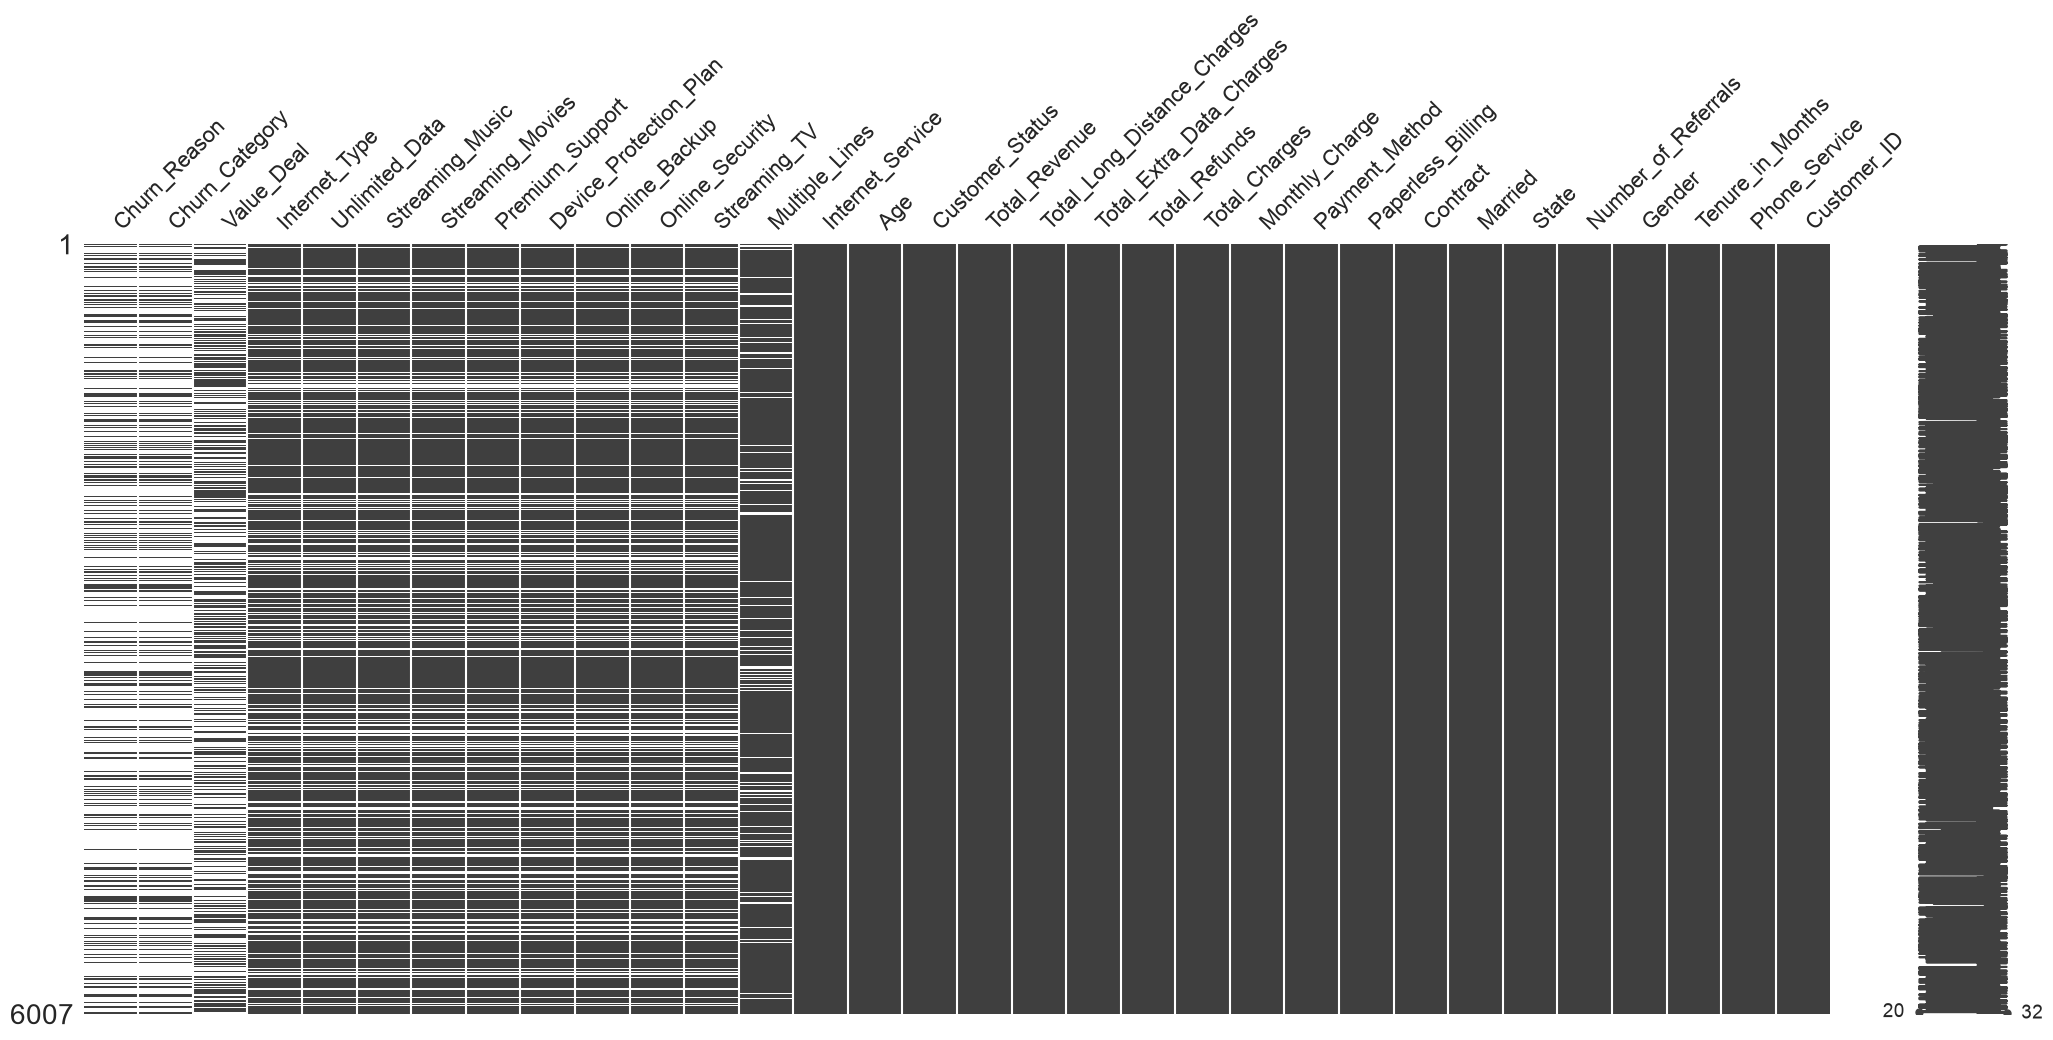

In [7]:
# Missing-value visualization sorted by internet variables
(
    df_model
    .missing.sort_variables_by_missingness()
    .pipe(missingno.matrix)
)

In [8]:
missing_variables = (
    df_model.missing.missing_variable_summary()
    .query("n_missing > 0")
    .sort_values("n_missing", ascending=False)
)

missing_variables


,variable,n_missing,n_cases,pct_missing
30,Churn_Category,4275,6007,71.166972
31,Churn_Reason,4275,6007,71.166972
7,Value_Deal,3297,6007,54.885966
11,Internet_Type,1223,6007,20.359580
12,Online_Security,1223,6007,20.359580
13,Online_Backup,1223,6007,20.359580
14,Device_Protection_Plan,1223,6007,20.359580
15,Premium_Support,1223,6007,20.359580
16,Streaming_TV,1223,6007,20.359580
17,Streaming_Movies,1223,6007,20.359580


`Churn_Category` and `Churn_Reason` top the table (71% missing) but aren't investigated as a missing-data problem: they only exist for customers who already churned (it's their reason for leaving), so they are a consequence of churn, not a predictor -- including them would be direct leakage. They're excluded from the model in `04_train_test_split.ipynb`, not imputed.

The rest of this section focuses on the 9 internet-dependent columns, which are genuinely missing values worth explaining.

### Testing the hypothesis

First, a visual cut: if `df_model` is sorted by `Internet_Service`, the missing-value matrix should show a solid block of missing values for one group and none for the other. Next, the following table confirms that cut with exact numbers: the missing rate should be 100% for `Internet_Service == "No"` and 0% for `Internet_Service == "Yes"`.

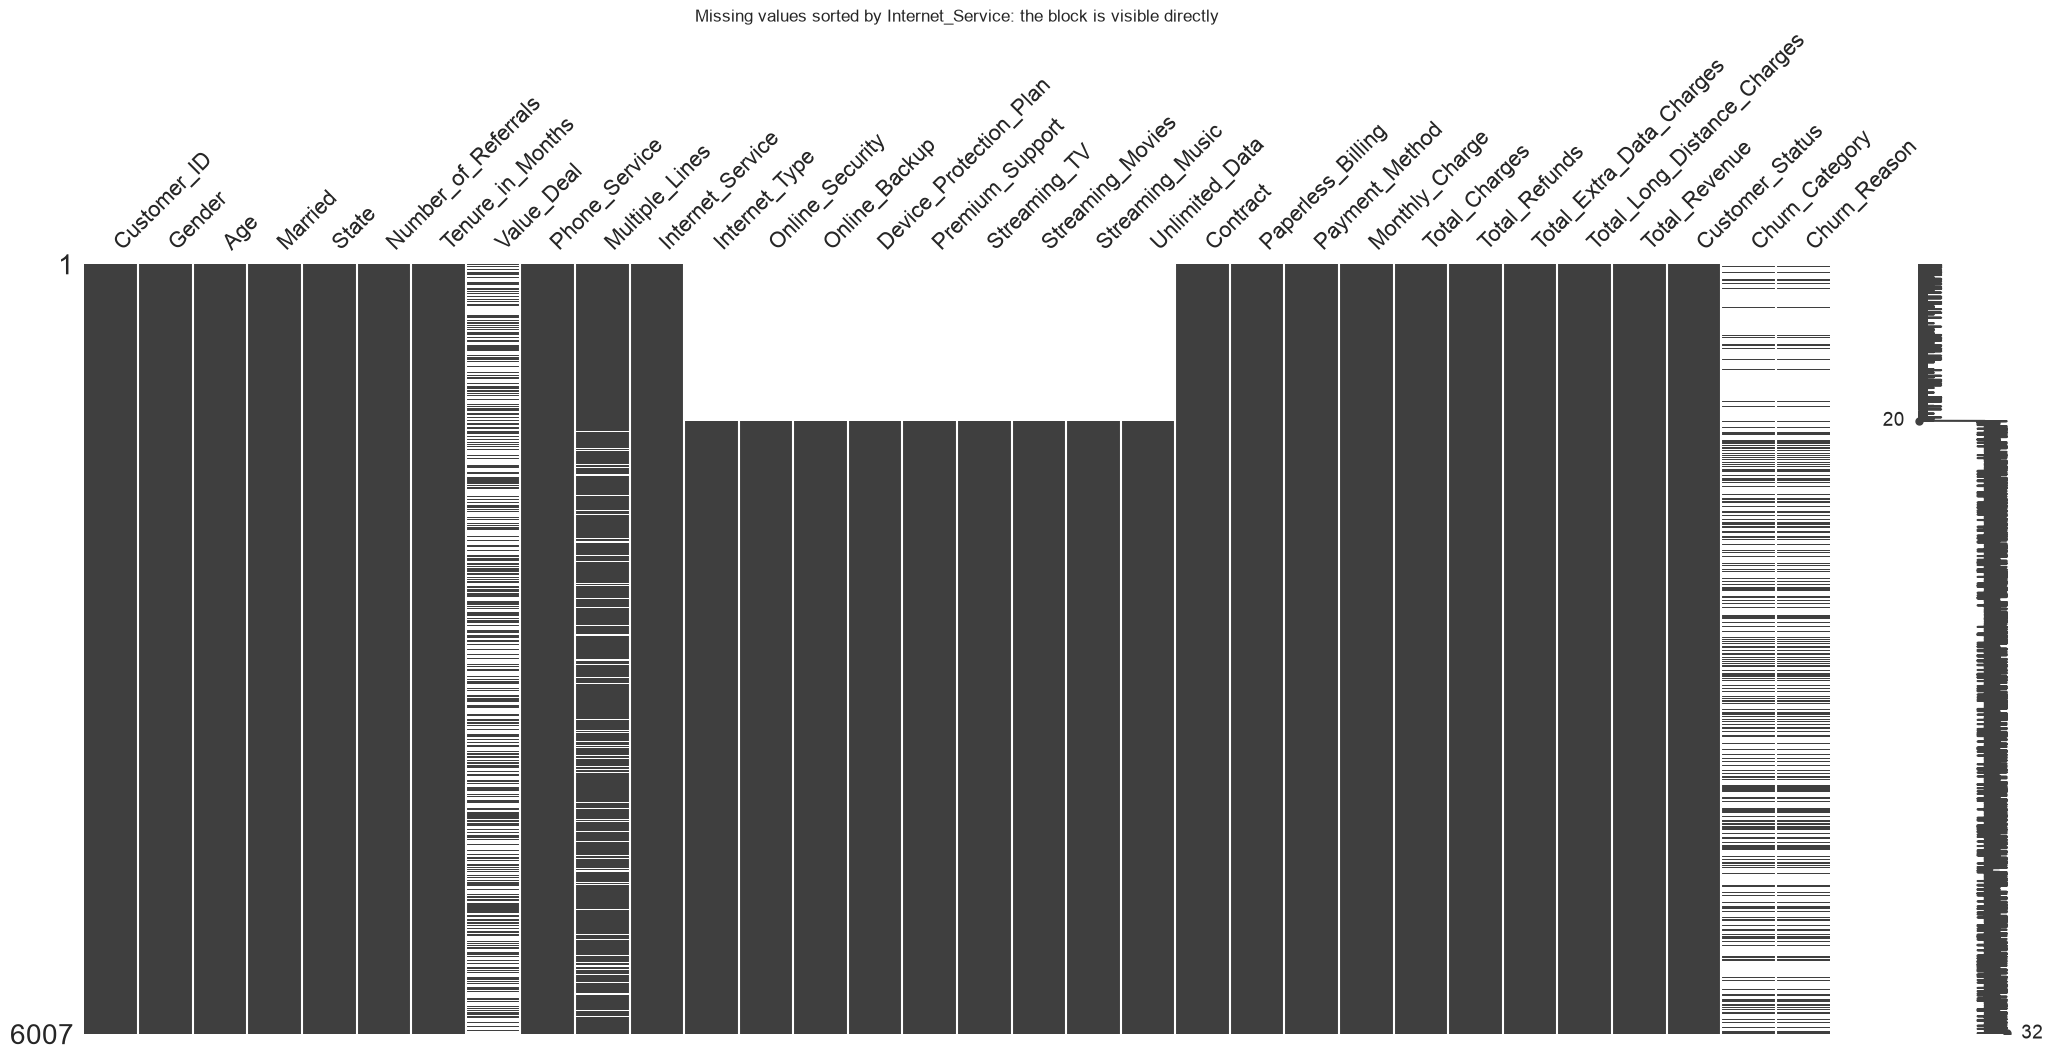

In [9]:
# Visual cut: missing values sorted by Internet_Service (not by missingness)
ax = (
    df_model
    .sort_values("Internet_Service")
    .pipe(missingno.matrix)
)
ax.set_title("Missing values sorted by Internet_Service: the block is visible directly")
plt.show()

In [10]:
internet_null_check = pd.DataFrame(
    {
        "variable": INTERNET_DEPENDENT_COLS,
        "n_missing": [df_model[col].isna().sum() for col in INTERNET_DEPENDENT_COLS],
        "n_missing_without_internet": [
            df_model.loc[df_model["Internet_Service"].eq("No"), col].isna().sum()
            for col in INTERNET_DEPENDENT_COLS
        ],
        "n_missing_with_internet": [
            df_model.loc[df_model["Internet_Service"].eq("Yes"), col].isna().sum()
            for col in INTERNET_DEPENDENT_COLS
        ],
    }
).assign(
    explained_by_no_internet=lambda data: data["n_missing"].eq(
        data["n_missing_without_internet"]
    )
    & data["n_missing_with_internet"].eq(0)
)

internet_null_check


,variable,n_missing,n_missing_without_internet,n_missing_with_internet,explained_by_no_internet
0,Internet_Type,1223,1223,0,True
1,Online_Security,1223,1223,0,True
2,Online_Backup,1223,1223,0,True
3,Device_Protection_Plan,1223,1223,0,True
4,Premium_Support,1223,1223,0,True
5,Streaming_TV,1223,1223,0,True
6,Streaming_Movies,1223,1223,0,True
7,Streaming_Music,1223,1223,0,True
8,Unlimited_Data,1223,1223,0,True


### Joint occurrences of missing values

One piece is missing: the previous table proves the missing values coincide with `Internet_Service == "No"`, but not that the nine columns are *always* missing together (there could be partial combinations). The UpSet plot shows this: if the pattern is structural, there should be a single dominant combination -- "all nine missing" -- and no partial combination with meaningful volume.

{'matrix': <Axes: >,
 'shading': <Axes: >,
 'totals': <Axes: >,
 'intersections': <Axes: ylabel='Intersection size'>}

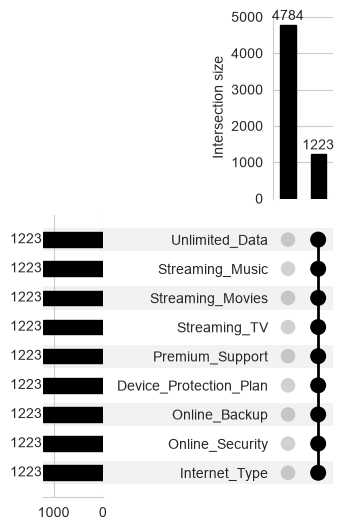

In [11]:
# Visualization of joint occurrences of missing values in internet variables
(
    df_model
    .missing
    .missing_upsetplot(
        variables=INTERNET_DEPENDENT_COLS,
        element_size=30,
        show_counts=True,
    )
)

### Conclusion

Three independent pieces of evidence agree: the visual cut when sorted by `Internet_Service`, the count table (100% missing without internet, 0% with internet), and the UpSet plot (a single dominant combination, no partial combinations). The missing values in these nine columns are not random capture errors -- they are structural, fully explained by `Internet_Service == "No"`.

That's why they are imputed as an explicit category (`No Internet Service`) in `04_train_test_split.ipynb`, instead of dropping valid rows.

## Numeric distributions by churn

The comparison uses `Monthly_Charge >= 0` to keep the detected anomaly from distorting the reading.

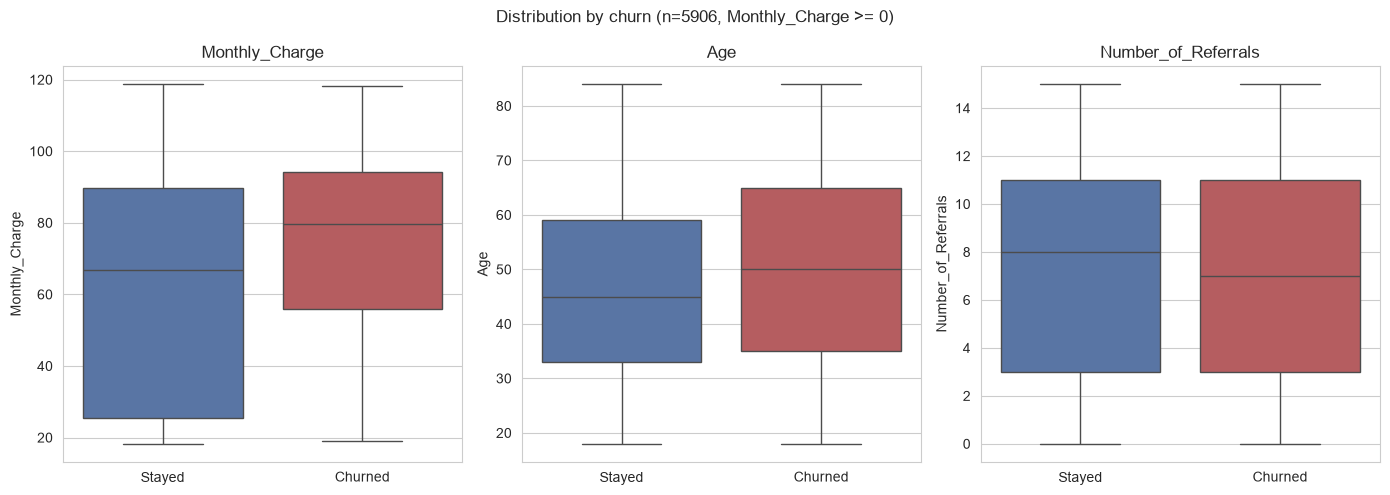

In [12]:
df_clean = df_model[df_model[MONTHLY_CHARGE_COL] >= 0].copy()
df_clean["churn_flag"] = (df_clean[TARGET_COL] == "Churned").astype(int)

box_cols = [MONTHLY_CHARGE_COL, "Age", "Number_of_Referrals"]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, box_cols):
    sns.boxplot(data=df_clean, x=TARGET_COL, y=col, hue=TARGET_COL, palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle(f"Distribution by churn (n={len(df_clean)}, Monthly_Charge >= 0)")
plt.tight_layout()
plt.show()

## Correlation of numeric variables

The matrix measures Pearson correlation against numeric variables and `churn_flag` (`1 = Churned`). It's useful for prioritizing relationships, not for concluding causality.

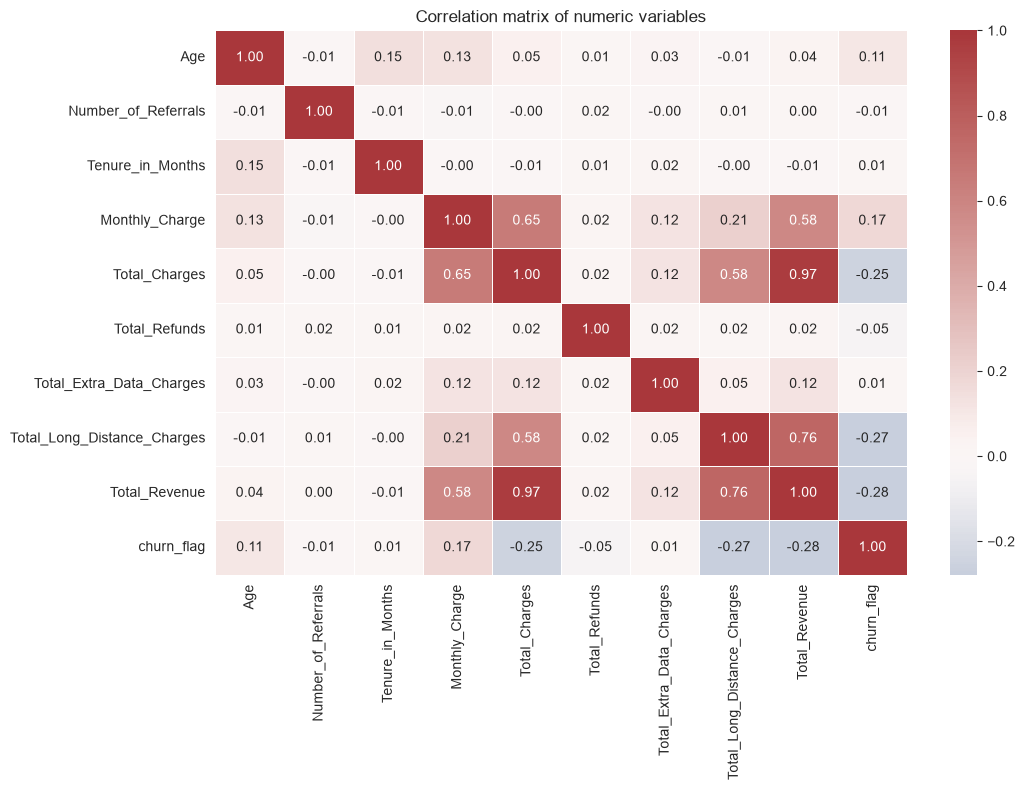

In [13]:
full_numeric_cols = [
    "Age", "Number_of_Referrals", "Tenure_in_Months", "Monthly_Charge",
    "Total_Charges", "Total_Refunds", "Total_Extra_Data_Charges",
    "Total_Long_Distance_Charges", "Total_Revenue", "churn_flag",
]
corr_matrix = df_clean[full_numeric_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", center=0, linewidths=0.5)
plt.title("Correlation matrix of numeric variables")
plt.tight_layout()
plt.show()

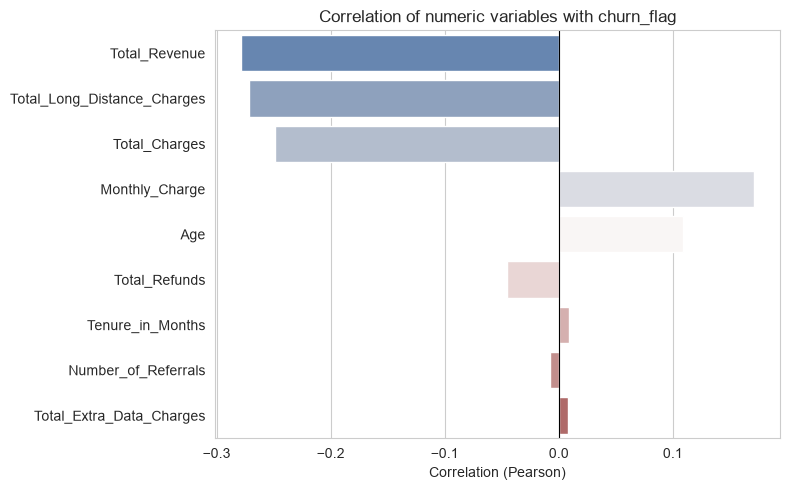

Total_Revenue                 -0.278804
Total_Long_Distance_Charges   -0.271306
Total_Charges                 -0.249086
Monthly_Charge                 0.171366
Age                            0.109168
Total_Refunds                 -0.045327
Tenure_in_Months               0.008592
Number_of_Referrals           -0.008000
Total_Extra_Data_Charges       0.007897
Name: churn_flag, dtype: float64

In [14]:
target_corr = corr_matrix["churn_flag"].drop("churn_flag").sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=target_corr.values, y=target_corr.index, hue=target_corr.index, palette="vlag", legend=False)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Correlation of numeric variables with churn_flag")
plt.xlabel("Correlation (Pearson)")
plt.ylabel("")
plt.tight_layout()
plt.show()
target_corr

`Total_Revenue` (-0.28) and `Total_Charges` (-0.25) are, in fact, the strongest numeric signal with churn -- stronger than `Monthly_Charge` (0.17). It's tempting to assume this happens because they capture customer tenure, but `Tenure_in_Months` correlates almost zero with both (-0.008 and -0.007) -- that's not it. The real reason these columns are excluded from the model isn't collinearity with tenure, but that their range depends on how long the customer has been accumulating charges since sign-up, which puts them out of range for `Joined` (diagnosed with data in `03_statistical_analysis.ipynb`, applied in `04_train_test_split.ipynb`).

## Association of categorical variables with churn (Cramer's V)

Cramer's V allows comparing the strength of association between categorical variables and churn on the same scale (0 to 1), unlike a raw chi-square which depends on sample size. The structural missing values identified above are converted to an explicit category before the calculation -- otherwise `pd.crosstab` would silently drop them and the result would be biased toward customers with internet service.

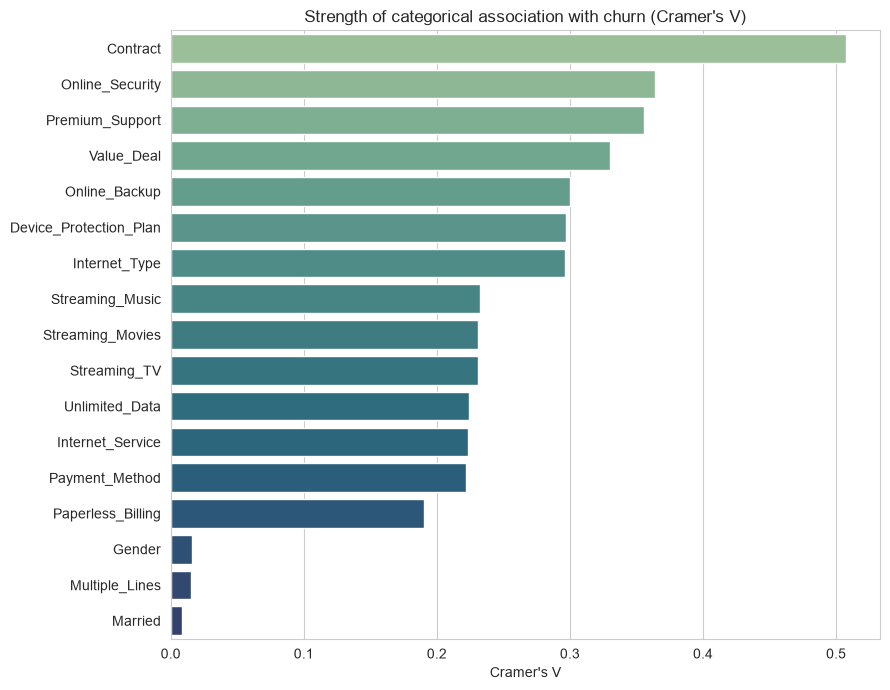

Contract                  0.507596
Online_Security           0.364002
Premium_Support           0.355460
Value_Deal                0.330278
Online_Backup             0.299758
Device_Protection_Plan    0.297311
Internet_Type             0.296477
Streaming_Music           0.232598
Streaming_Movies          0.230847
Streaming_TV              0.230656
Unlimited_Data            0.224165
Internet_Service          0.223465
Payment_Method            0.221944
Paperless_Billing         0.189989
Gender                    0.015871
Multiple_Lines            0.014880
Married                   0.008794
dtype: float64

In [15]:
import numpy as np


def cramers_v(x, y):
    table = pd.crosstab(x, y)
    observed = table.to_numpy(dtype=float)
    n = observed.sum()
    row_totals = observed.sum(axis=1, keepdims=True)
    col_totals = observed.sum(axis=0, keepdims=True)
    expected = row_totals @ col_totals / n
    chi2_stat = np.divide(
        (observed - expected) ** 2, expected,
        out=np.zeros_like(observed), where=expected > 0,
    ).sum()
    r, k = observed.shape
    return np.sqrt((chi2_stat / n) / max(1, min(k - 1, r - 1)))


categorical_cols = [
    "Contract", "Internet_Service", "Payment_Method", "Value_Deal",
    "Married", "Paperless_Billing", "Gender", "Multiple_Lines",
] + INTERNET_DEPENDENT_COLS

df_cat = df_clean.copy()
for col in INTERNET_DEPENDENT_COLS:
    df_cat[col] = df_cat[col].fillna("No Internet Service")
df_cat["Multiple_Lines"] = df_cat["Multiple_Lines"].fillna("No Phone Service")
df_cat["Value_Deal"] = df_cat["Value_Deal"].fillna("No Deal")

assoc = pd.Series(
    {col: cramers_v(df_cat[col], df_cat[TARGET_COL]) for col in categorical_cols}
).sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=assoc.values, y=assoc.index, hue=assoc.index, palette="crest", legend=False)
plt.title("Strength of categorical association with churn (Cramer's V)")
plt.xlabel("Cramer's V")
plt.ylabel("")
plt.tight_layout()
plt.show()
assoc

## Summary

- `Contract` and `Value_Deal` are the categorical variables with the strongest association with churn (Cramer's V); internet services contribute a moderate signal.
- `Total_Revenue` and `Total_Charges` are the strongest numeric signal with churn, but not because of tenure (correlation with `Tenure_in_Months` is nearly zero) -- they are excluded from the model because their range depends on how long the customer has been accumulating charges, which puts them out of range for `Joined`.
- `Monthly_Charge` is a useful numeric signal, but requires filtering out 107 negative rows: they are whole numbers almost perfectly (100% vs. ~5.5% in the rest), evidence of synthetic data rather than a real business rule.
- The missing values in the 9 internet-dependent columns are structural (`Internet_Service == "No"`), confirmed with three independent pieces of evidence -- they are imputed as a category, not dropped as rows.
- The cleaning and exclusion decisions are applied in `04_train_test_split.ipynb`; the diagnosis of `Total_Charges`/`Total_Revenue` being out of range for `Joined` is detailed in `03_statistical_analysis.ipynb`.